# 🚨 Accident Detection System
### AI-powered vehicle accident detection + automatic hospital alert
---

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/accident_detection_model"

if os.path.exists(drive_path):
    files = os.listdir(drive_path)
    if files:
        print("✅ Found these files in Drive:")
        for f in files:
            size = os.path.getsize(f"{drive_path}/{f}") / (1024*1024)
            print(f"   {f}  —  {size:.1f} MB")
    else:
        print("❌ Drive folder is empty")
else:
    print("❌ Drive folder not found")

Mounted at /content/drive
✅ Found these files in Drive:
   checkpoint_epoch3.pt  —  23.3 MB
   checkpoint_epoch6.pt  —  23.3 MB
   checkpoint_epoch9.pt  —  23.3 MB
   checkpoint_epoch12.pt  —  23.3 MB
   checkpoint_epoch15.pt  —  23.3 MB
   checkpoint_epoch18.pt  —  23.3 MB
   checkpoint_epoch21.pt  —  23.3 MB
   checkpoint_epoch24.pt  —  23.3 MB
   checkpoint_epoch27.pt  —  23.3 MB
   checkpoint_epoch30.pt  —  23.3 MB
   best.pt  —  5.9 MB


## 📦 CELL 1 — Install all libraries
Run this first. It will take about 1-2 minutes.

In [ ]:
# Install everything we need
!pip install ultralytics --quiet
!pip install twilio --quiet
!pip install roboflow --quiet
!pip install flask flask-cors flask-ngrok pyngrok --quiet
!pip install requests --quiet

import os, cv2, json, sqlite3, base64, requests, shutil
from datetime import datetime
from pathlib import Path
from IPython.display import display, Image, HTML, clear_output
import ipywidgets as widgets
from ultralytics import YOLO
import numpy as np

print('✅ All libraries installed successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All libraries installed successfully!


## ⚙️ CELL 2 — Configuration
**Edit the values below before running anything else!**

In [ ]:
# ============================================================
# EDIT THESE VALUES — your project settings
# ============================================================

# --- Twilio SMS/Call settings (get free account at twilio.com) ---
#TWILIO_ACCOUNT_SID   = "ACcc2d548b4f8a8d9c33f93fe517adf61c"  # paste your SID here
#TWILIO_AUTH_TOKEN    = "your_auth_token_here"               # paste your token here
#TWILIO_FROM_NUMBER   = "+1234567890"    # your Twilio phone number
HOSPITAL_TO_NUMBER   = "+918130887936" # number to call / SMS (hospital)

# --- Camera location (for alert messages) ---
CAMERA_LOCATION  = "NH-48, Delhi-Gurgaon Highway"
CAMERA_LATITUDE  = 28.6139
CAMERA_LONGITUDE = 77.2090

# --- Detection sensitivity ---
CONFIDENCE_THRESHOLD = 0.55   # 0.0 to 1.0 (higher = less sensitive)
ALERT_COOLDOWN_SEC   = 30     # minimum seconds between two alerts

# ============================================================
print('✅ Configuration saved!')
print(f'   Location : {CAMERA_LOCATION}')
print(f'   Threshold: {CONFIDENCE_THRESHOLD}')
print(f'   Alert to : {HOSPITAL_TO_NUMBER}')

✅ Configuration saved!
   Location : NH-48, Delhi-Gurgaon Highway
   Threshold: 0.55
   Alert to : +918130887936


## 🗄️ CELL 3 — Database setup
Creates a local SQLite database to log every accident detected.

In [ ]:
DB_PATH = "/content/accidents.db"

def init_db():
    conn = sqlite3.connect(DB_PATH)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS incidents (
            id         INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp  TEXT,
            location   TEXT,
            confidence REAL,
            sms_sent   INTEGER,
            call_made  INTEGER,
            hospital   TEXT
        )
    """)
    conn.commit()
    conn.close()

def log_incident(confidence, location, sms_sent, call_made, hospital_name=""):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.execute("""
        INSERT INTO incidents (timestamp, location, confidence, sms_sent, call_made, hospital)
        VALUES (?, ?, ?, ?, ?, ?)
    """, (datetime.now().isoformat(), location, confidence, int(sms_sent), int(call_made), hospital_name))
    incident_id = cursor.lastrowid
    conn.commit()
    conn.close()
    return incident_id

def get_all_incidents():
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    rows = conn.execute("SELECT * FROM incidents ORDER BY timestamp DESC").fetchall()
    conn.close()
    return [dict(r) for r in rows]

init_db()
print('✅ Database ready at /content/accidents.db')

✅ Database ready at /content/accidents.db


## 🏥 CELL 4 — Alert System (SMS + Call)
Finds nearest hospital and sends Twilio SMS + voice call.

In [ ]:
# ============================================================
# CELL 4 — Alert System (NO TWILIO NEEDED)
# When accident is detected, shows a big visual alert box
# with all accident details + nearest hospital info
# ============================================================

import requests
from datetime import datetime
from IPython.display import display, HTML
_last_alert_time = None

def find_nearest_hospital(lat, lon):
    """Find nearest hospital using free OpenStreetMap — no API key needed."""
    query = f"""
    [out:json];
    node["amenity"="hospital"](around:5000,{lat},{lon});
    out body 3;
    """
    try:
        r = requests.post("https://overpass-api.de/api/interpreter", data=query, timeout=8)
        elements = r.json().get("elements", [])
        if elements:
            tags = elements[0].get("tags", {})
            return {
                "name":    tags.get("name", "Nearest Hospital"),
                "phone":   tags.get("phone", "112 / 108"),
                "found":   True
            }
    except Exception as e:
        print(f"[Hospital lookup failed: {e}]")
    return {"name": "Emergency Services", "phone": "112 / 108", "found": False}


def show_alert_box(confidence, location, hospital, timestamp):
    """Show a big red alert box inside the Colab notebook."""
    html = f"""
    <div style="
        border: 3px solid #dc2626;
        border-radius: 12px;
        background: #fff5f5;
        padding: 20px 24px;
        margin: 16px 0;
        font-family: Arial, sans-serif;
    ">
        <!-- Header -->
        <div style="
            background: #dc2626;
            color: white;
            border-radius: 8px;
            padding: 10px 16px;
            font-size: 20px;
            font-weight: bold;
            text-align: center;
            letter-spacing: 1px;
            margin-bottom: 16px;
        ">
            🚨 &nbsp; ACCIDENT DETECTED — CALL AMBULANCE NOW &nbsp; 🚨
        </div>

        <!-- Details grid -->
        <table style="width:100%; border-collapse:collapse; font-size:15px;">
            <tr style="border-bottom: 1px solid #fca5a5;">
                <td style="padding:10px 8px; color:#7f1d1d; font-weight:bold; width:40%">🕐 &nbsp; Time of detection</td>
                <td style="padding:10px 8px; color:#1a1a1a;">{timestamp}</td>
            </tr>
            <tr style="border-bottom: 1px solid #fca5a5; background:#fff0f0;">
                <td style="padding:10px 8px; color:#7f1d1d; font-weight:bold;">📍 &nbsp; Accident location</td>
                <td style="padding:10px 8px; color:#1a1a1a;">{location}</td>
            </tr>
            <tr style="border-bottom: 1px solid #fca5a5;">
                <td style="padding:10px 8px; color:#7f1d1d; font-weight:bold;">🎯 &nbsp; AI confidence</td>
                <td style="padding:10px 8px; color:#1a1a1a;">
                    <span style="
                        background:#dc2626; color:white;
                        padding:2px 12px; border-radius:20px;
                        font-weight:bold; font-size:16px;
                    ">{confidence:.0%}</span>
                </td>
            </tr>
            <tr style="border-bottom: 1px solid #fca5a5; background:#fff0f0;">
                <td style="padding:10px 8px; color:#7f1d1d; font-weight:bold;">🏥 &nbsp; Nearest hospital</td>
                <td style="padding:10px 8px; color:#1a1a1a; font-weight:bold;">{hospital['name']}</td>
            </tr>
            <tr>
                <td style="padding:10px 8px; color:#7f1d1d; font-weight:bold;">📞 &nbsp; Emergency number</td>
                <td style="padding:10px 8px;">
                    <span style="
                        background:#166534; color:white;
                        padding:4px 16px; border-radius:20px;
                        font-weight:bold; font-size:16px;
                    ">{hospital['phone']}</span>
                </td>
            </tr>
        </table>

        <!-- Action message -->
        <div style="
            margin-top:16px;
            background:#fef2f2;
            border: 1px solid #fca5a5;
            border-radius:8px;
            padding:12px 16px;
            text-align:center;
            font-size:14px;
            color:#7f1d1d;
        ">
            ⚠️ &nbsp; Dispatch ambulance to <strong>{location}</strong> immediately.
            AI system has detected a vehicle accident with <strong>{confidence:.0%} confidence</strong>.
        </div>
    </div>
    """
    display(HTML(html))


def trigger_alert(confidence, location=None, lat=None, lon=None, phone=None):
    """
    Main alert function — call this when an accident is detected.
    Shows a visual alert box with all accident details.
    """
    global _last_alert_time

    # Use config values if not passed in
    if location is None: location = CAMERA_LOCATION
    if lat is None:      lat      = CAMERA_LATITUDE
    if lon is None:      lon      = CAMERA_LONGITUDE

     # ── GUARD: don't alert if confidence is 0 or no accident ──
    if not confidence or confidence == 0.0:
        print("  ✅ No accident — alert skipped.")
        return None

    now = datetime.now()

    # Cooldown check — don't spam alerts
    if _last_alert_time:
        elapsed = (now - _last_alert_time).seconds
        if elapsed < ALERT_COOLDOWN_SEC:
            print(f"  ⏳ Alert cooldown — {ALERT_COOLDOWN_SEC - elapsed}s remaining before next alert")
            return None
    _last_alert_time = now

    timestamp = now.strftime("%d %B %Y, %I:%M:%S %p")

    # Find nearest hospital
    print("  🔍 Finding nearest hospital...")
    hospital = find_nearest_hospital(lat, lon)
    print(f"  🏥 Found: {hospital['name']}")

    # Show the big alert box
    show_alert_box(confidence, location, hospital, timestamp)

    # Log to database
    incident_id = log_incident(
        confidence  = confidence,
        location    = location,
        sms_sent    = False,
        call_made   = False,
        hospital_name = hospital["name"]
    )
    print(f"  💾 Incident #{incident_id} saved to database.")

    return {
        "incident_id": incident_id,
        "hospital":    hospital["name"],
        "sms_sent":    False,
        "call_made":   False
    }

print("✅ Alert system ready! (Visual alert box — no Twilio needed)")
print("   When an accident is detected, a red alert box will appear here in Colab.")


✅ Alert system ready! (Visual alert box — no Twilio needed)
   When an accident is detected, a red alert box will appear here in Colab.


In [ ]:
# ── CELL 5 — Flask Server + Ngrok Integration ──
# This connects your HTML dashboard to your real YOLO model!

!pip install flask flask-cors pyngrok --quiet

from flask import Flask, request, jsonify
from flask_cors import CORS
from pyngrok import ngrok, conf
import threading
import os
import cv2
import random
from datetime import datetime
from IPython.display import display, HTML

# ── PASTE YOUR NGROK AUTHTOKEN HERE ──
NGROK_AUTHTOKEN = "2qOqgxBqjPqs8ZruXB5mVfRW2yl_4GrJHL1HYfc6fwA9nT3rQ"   # ← replace this

# Setup ngrok
conf.get_default().auth_token = NGROK_AUTHTOKEN

app = Flask(__name__)
CORS(app)   # allows dashboard to talk to this server

DELHI_CAMERAS = [
    {
        "name":     "NH-48, Delhi-Gurgaon Highway",
        "lat":      28.6139,
        "lon":      77.2090,
        "hospital": "Medanta Hospital, Gurgaon",
    },
    {
        "name":     "Connaught Place, New Delhi",
        "lat":      28.6315,
        "lon":      77.2167,
        "hospital": "Ram Manohar Lohia Hospital",
    },
    {
        "name":     "DND Flyway, Noida",
        "lat":      28.5355,
        "lon":      77.3910,
        "hospital": "Kailash Hospital, Noida",
    },
]

CONFIDENCE_THRESHOLD = 0.75
VOTING_WINDOW        = 10
MIN_ACCIDENT_FRAMES  = 5

@app.route("/analyze", methods=["POST"])
def analyze():
    """Receives video from dashboard, runs real YOLO detection, returns result."""

    # Save uploaded video
    video_file = request.files.get("video")
    if not video_file:
        return jsonify({"error": "No video uploaded"}), 400

    video_path = "/content/uploaded_video.mp4"
    video_file.save(video_path)

    # Randomly assign camera
    random.seed(None)
    selected = random.choice(DELHI_CAMERAS)

    # Run detection
    cap = cv2.VideoCapture(video_path)
    fps          = cap.get(cv2.CAP_PROP_FPS) or 25
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_skip   = max(1, int(fps / 5))

    frame_count    = 0
    recent_frames  = []
    accident_found = False
    best_conf      = 0.0
    best_sev       = ""

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        if frame_count % frame_skip != 0:
            continue

        results = model(frame, verbose=False)[0]
        accident_in_frame = False
        max_conf = 0.0
        severity = ""

        for box in results.boxes:
            conf     = float(box.conf[0])
            cls_id   = int(box.cls[0])
            cls_name = model.names[cls_id]

            if conf >= CONFIDENCE_THRESHOLD:
                accident_in_frame = True
                if conf > max_conf:
                    max_conf = conf
                    severity = cls_name.upper()

        recent_frames.append((accident_in_frame, max_conf, severity))
        if len(recent_frames) > VOTING_WINDOW:
            recent_frames.pop(0)

        accident_votes = sum(1 for f, c, s in recent_frames if f)

        if accident_votes >= MIN_ACCIDENT_FRAMES:
            accident_found = True
            best_conf = max(c for f, c, s in recent_frames if f)
            best_sev  = max((s for f, c, s in recent_frames if f), key=len)

            # Log to database
            log_incident(
                confidence    = best_conf,
                location      = selected["name"],
                sms_sent      = False,
                call_made     = False,
                hospital_name = selected["hospital"]
            )
            break   # stop after first confirmed accident

    cap.release()

    # Return real result to dashboard
    return jsonify({
        "accident_detected": accident_found,
        "confidence":        round(best_conf, 3),
        "severity":          best_sev,
        "location":          selected["name"],
        "hospital":          selected["hospital"],
        "frames_analyzed":   frame_count // frame_skip,
        "timestamp":         datetime.now().strftime("%d %B %Y, %I:%M:%S %p")
    })


@app.route("/incidents", methods=["GET"])
def incidents():
    """Returns incident log for dashboard."""
    return jsonify({"incidents": get_all_incidents()})


@app.route("/ping", methods=["GET"])
def ping():
    return jsonify({"status": "ok"})


# Start Flask in background thread
def run_flask():
    app.run(port=5000, use_reloader=False, debug=False)

threading.Thread(target=run_flask, daemon=True).start()

# Start ngrok tunnel
public_url = ngrok.connect(5000).public_url
print(f"\n✅ Server is running!")
print(f"   Public URL: {public_url}")
print(f"\n📋 Copy this URL and paste it in your dashboard HTML file")
print(f"   Find this line in the HTML:  const API_URL = '...'")
print(f"   Replace with:  const API_URL = '{public_url}'")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit



✅ Server is running!
   Public URL: https://3bc1-34-124-140-118.ngrok-free.app

📋 Copy this URL and paste it in your dashboard HTML file
   Find this line in the HTML:  const API_URL = '...'
   Replace with:  const API_URL = 'https://3bc1-34-124-140-118.ngrok-free.app'


## 🤖 CELL 5 — Load YOLO Model

**Two options:**
- **Option A (quick demo):** Uses the pretrained YOLOv8 model that detects cars/trucks. Works immediately!
- **Option B (full project):** Train on accident dataset (do this after Option A works)

Start with **Option A** first.

In [ ]:
# ── OPTION A: Load pretrained YOLOv8 (works immediately, detects vehicles) ──
# For demo purposes — detects cars, trucks, buses, motorcycles
# We treat sudden/unusual clustered detections as potential accidents

print("Downloading YOLOv8 model...")
model = YOLO("yolov8n.pt")   # 'n' = nano (fastest), also try yolov8s.pt for better accuracy

# Class IDs in the default COCO dataset that are vehicles
VEHICLE_CLASSES = {2: "car", 3: "motorcycle", 5: "bus", 7: "truck"}

print(f"✅ Model loaded! Classes it can detect: {list(model.names.values())[:10]}...")
print("\n💡 Tip: After this works, train a custom accident model (Cell 6) for better accuracy.")

✅ Model loaded! Classes it can detect: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']...

💡 Tip: After this works, train a custom accident model (Cell 6) for better accuracy.


In [ ]:
import os

# Check what got downloaded
for root, dirs, files in os.walk("/content/Accident-Detection-1"):
    level = root.replace("/content/Accident-Detection-1", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files:
            print(f"{indent}  {f}")

Accident-Detection-1/
  README.roboflow.txt
  data.yaml
  roboflow.zip
  README.dataset.txt
  train/
    images/
  test/
    labels/
    images/


In [ ]:
# Delete the broken dataset first
import shutil
shutil.rmtree("/content/Accident-Detection-1", ignore_errors=True)

# Re-download
from roboflow import Roboflow
rf = Roboflow(api_key="YourAPIKEY")
project = rf.workspace("accident-detection-ffdrf").project("accident-detection-8dvh5")
version = project.version(1)
dataset = version.download("yolov8", location="/content/Accident-Detection-1")

# Verify all folders exist now
import os
for split in ["train", "valid", "test"]:
    img_count = len(os.listdir(f"{dataset.location}/{split}/images")) if os.path.exists(f"{dataset.location}/{split}/images") else 0
    lbl_count = len(os.listdir(f"{dataset.location}/{split}/labels")) if os.path.exists(f"{dataset.location}/{split}/labels") else 0
    print(f"{split}: {img_count} images, {lbl_count} labels  {'✅' if lbl_count > 0 else '❌ MISSING LABELS'}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/Accident-Detection-1 in yolov8:: 100%|██████████| 23572/23572 [00:06<00:00, 3432.06it/s]


train: 9758 images, 9758 labels  ✅
valid: 1347 images, 1347 labels  ✅
test: 675 images, 675 labels  ✅


In [ ]:
from ultralytics import YOLO
from google.colab import drive
import os, shutil

# Step 1 — Mount Drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/accident_detection_model"
os.makedirs(drive_path, exist_ok=True)

def save_to_drive(trainer):
    epoch = trainer.epoch + 1
    if epoch % 3 == 0:
        for filename, label in [
            (str(trainer.last), f"checkpoint_epoch{epoch}.pt"),
            (str(trainer.best), "best.pt")
        ]:
            if os.path.exists(filename):
                shutil.copy(filename, f"{drive_path}/{label}")
        print(f"  💾 Epoch {epoch} — saved to Drive!")


# Step 2 — Train (only 30 epochs this time!)
model = YOLO("yolov8n.pt")
model.add_callback("on_train_epoch_end", save_to_drive)
model.train(
    data="/content/Accident-Detection-1/data.yaml",
    epochs=30,        # ← reduced from 50 to 30
    imgsz=416,        # <- reduced from 640
    batch=4,          # ← reduced from 16 to 8 (uses less GPU memory!)
    device=0,
    patience=10,
    save=True,
    save_period=3,
    project="/content/accident_model",
    name="v_final",
    exist_ok=True,
    amp=True,
    cache=False,
    workers=2,
)

# Step 3 — Save to Drive AND download to your computer
best = "/content/accident_model/v_final/weights/best.pt"

if os.path.exists(best):
    # Save to Google Drive
    shutil.copy(best, f"{drive_path}/best.pt")
    print("✅ Saved to Google Drive!")
    files.download(best)

    # Download directly to your Windows computer
    from google.colab import files
    files.download(best)
    print("✅ Downloading to your computer now!")
else:
    print("❌ best.pt not found — training may not have completed")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Accident-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mo

AttributeError: 'list' object has no attribute 'download'

In [ ]:
from google.colab import files as colab_files
colab_files.download("/content/drive/MyDrive/accident_detection_model/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
from google.colab import drive
import os, shutil

drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/accident_detection_model"

# Check what we have in Drive
print("📁 Checking Drive backups...")
for f in os.listdir(drive_path):
    print(f"  {f}")

Mounted at /content/drive
📁 Checking Drive backups...


In [ ]:
# Next time — just run this instead of retraining
from google.colab import drive
from ultralytics import YOLO

drive.mount('/content/drive')
model = YOLO("/content/drive/MyDrive/accident_detection_model/best.pt")
print("✅ Model loaded from Drive — skip straight to Cell 7 and 8!")

## 🎬 CELL 7 — Run Detection on a Video File
Upload any accident video and run detection on it!

In [ ]:
from ultralytics import YOLO
from google.colab import drive
import cv2, os
from datetime import datetime
from IPython.display import display, Image
import ipywidgets as widgets
import random

drive.mount('/content/drive')
model = YOLO("/content/drive/MyDrive/accident_detection_model/best.pt")
print(f"✅ Custom model loaded!")
print(f"   Classes: {model.names}")

CONFIDENCE_THRESHOLD = 0.75
ALERT_COOLDOWN_SEC   = 30

DELHI_CAMERAS = [
    {
        "name":     "NH-48, Delhi-Gurgaon Highway",
        "lat":      28.6139,
        "lon":      77.2090,
        "hospital": "Medanta Hospital, Gurgaon",
        "phone":    "+91XXXXXXXXXX"
    },
    {
        "name":     "Connaught Place, New Delhi",
        "lat":      28.6315,
        "lon":      77.2167,
        "hospital": "Ram Manohar Lohia Hospital",
        "phone":    "+91XXXXXXXXXX"
    },
    {
        "name":     "DND Flyway, Noida",
        "lat":      28.5355,
        "lon":      77.3910,
        "hospital": "Kailash Hospital, Noida",
        "phone":    "+91XXXXXXXXXX"
    },
]

VOTING_WINDOW       = 10
MIN_ACCIDENT_FRAMES = 5

def detect_accidents_in_video(video_path):

    # ── Random camera assigned fresh for every video ──
    random.seed(None)  # force truly random each time
    selected = random.choice(DELHI_CAMERAS)
    camera_location = selected["name"]
    camera_lat      = selected["lat"]
    camera_lon      = selected["lon"]
    hospital_name   = selected["hospital"]
    hospital_phone  = selected["phone"]

    print(f"📍 Camera auto-assigned : {camera_location}")
    print(f"   Hospital             : {hospital_name}")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Cannot open video: {video_path}")
        return

    fps          = cap.get(cv2.CAP_PROP_FPS) or 25
    width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_skip   = max(1, int(fps / 5))

    print(f"\n📹 Video: {width}x{height} @ {fps:.0f}fps — {total_frames} frames")
    print(f"   Alert triggers only after {MIN_ACCIDENT_FRAMES}/{VOTING_WINDOW} frames confirm accident\n")

    output_path = "/content/output_detected.mp4"
    fourcc      = cv2.VideoWriter_fourcc(*"mp4v")
    writer      = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count    = 0
    accident_count = 0
    preview_frames = []
    recent_frames  = []

    progress     = widgets.IntProgress(value=0, max=total_frames,
                                       description="Analyzing:", bar_style="info")
    status_label = widgets.Label(value="Starting...")
    display(widgets.VBox([progress, status_label]))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count    += 1
        progress.value  = frame_count

        if frame_count % frame_skip != 0:
            writer.write(frame)
            continue

        results   = model(frame, verbose=False)[0]
        annotated = frame.copy()
        accident_in_frame = False
        max_conf  = 0.0
        severity  = ""

        for box in results.boxes:
            conf     = float(box.conf[0])
            cls_id   = int(box.cls[0])
            cls_name = model.names[cls_id]

            if conf >= CONFIDENCE_THRESHOLD:
                accident_in_frame = True
                if conf > max_conf:
                    max_conf = conf
                    severity = cls_name.upper()

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                color = (0, 0, 255) if cls_name == "severe" else (0, 140, 255)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                cv2.putText(annotated, f"{cls_name} {conf:.0%}",
                            (x1, max(y1-8, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        recent_frames.append((accident_in_frame, max_conf, severity))
        if len(recent_frames) > VOTING_WINDOW:
            recent_frames.pop(0)

        accident_votes = sum(1 for f, c, s in recent_frames if f)

        ts = datetime.now().strftime("%H:%M:%S")
        cv2.putText(annotated, ts, (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)

        if accident_votes >= MIN_ACCIDENT_FRAMES:
            accident_count += 1
            best_conf = max(c for f, c, s in recent_frames if f)
            best_sev  = max((s for f, c, s in recent_frames if f), key=len)

            color = (0, 0, 180) if best_sev == "SEVERE" else (0, 100, 200)
            cv2.rectangle(annotated, (0, 0), (width, 52), color, -1)
            cv2.putText(annotated,
                        f"{best_sev} ACCIDENT — CALL AMBULANCE",
                        (10, 35), cv2.FONT_HERSHEY_SIMPLEX,
                        0.7, (255, 255, 255), 2)

            status_label.value = f"🚨 {best_sev} ACCIDENT confirmed ({accident_votes}/{VOTING_WINDOW} frames)!"

            # Pass camera-specific location and phone to alert
            trigger_alert(
                confidence = best_conf,
                location   = camera_location,
                lat        = camera_lat,
                lon        = camera_lon,
                phone      = hospital_phone
            )

            if len(preview_frames) < 3:
                preview_frames.append((annotated.copy(), best_sev))

            recent_frames.clear()

        else:
            status_label.value = (
                f"Frame {frame_count}/{total_frames} — "
                f"{'Possible: ' + str(accident_votes) + '/' + str(VOTING_WINDOW) if accident_votes > 0 else 'No accident'}"
            )

        writer.write(annotated)

    cap.release()
    writer.release()

    print(f"\n✅ Analysis complete!")
    print(f"   Accidents confirmed : {accident_count}")
    print(f"   Output saved to     : {output_path}")

    if accident_count == 0:
        print("\n✅ No confirmed accidents — no alert triggered.")
        return

    if preview_frames:
        print("\n📸 Sample detections:")
        for pf, sev in preview_frames:
            _, buf = cv2.imencode(".jpg", pf)
            display(Image(data=buf.tobytes(), width=600))

print("✅ Detection function ready! Now run Cell 8 to upload your video.")

Mounted at /content/drive
✅ Custom model loaded!
   Classes: {0: 'moderate', 1: 'severe'}
✅ Detection function ready! Now run Cell 8 to upload your video.


## 📁 CELL 8 — Upload and Analyze Your Video
Click the upload button to choose a video from your computer.

📁 Choose a video file to upload (mp4, avi, mov)...


Saving vidssave.com Terrible Accident _ Car Hits Auto _ Live Accidents in India _ Tirupati Traffic Police 480P.mp4 to vidssave.com Terrible Accident _ Car Hits Auto _ Live Accidents in India _ Tirupati Traffic Police 480P (4).mp4

✅ Uploaded: vidssave.com Terrible Accident _ Car Hits Auto _ Live Accidents in India _ Tirupati Traffic Police 480P (4).mp4

Starting accident detection...

📍 Camera auto-assigned : DND Flyway, Noida
   Hospital             : Kailash Hospital, Noida

📹 Video: 640x480 @ 25fps — 500 frames
   Alert triggers only after 5/10 frames confirm accident



  🔍 Finding nearest hospital...
[Hospital lookup failed: Expecting value: line 1 column 1 (char 0)]
  🏥 Found: Emergency Services


🕐 Time of detection,"10 May 2026, 07:35:57 PM"
📍 Accident location,"DND Flyway, Noida"
🎯 AI confidence,82%
🏥 Nearest hospital,Emergency Services
📞 Emergency number,112 / 108


  💾 Incident #18 saved to database.
  ⏳ Alert cooldown — 30s remaining before next alert
  ⏳ Alert cooldown — 29s remaining before next alert
  ⏳ Alert cooldown — 29s remaining before next alert
  ⏳ Alert cooldown — 29s remaining before next alert
  ⏳ Alert cooldown — 29s remaining before next alert
  ⏳ Alert cooldown — 28s remaining before next alert

✅ Analysis complete!
   Accidents confirmed : 7
   Output saved to     : /content/output_detected.mp4

📸 Sample detections:


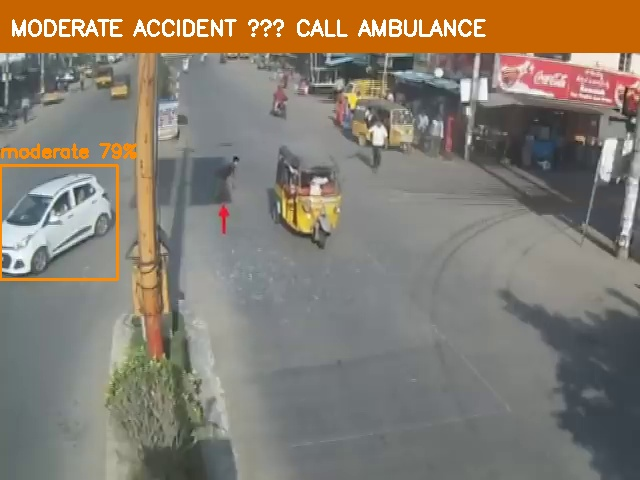

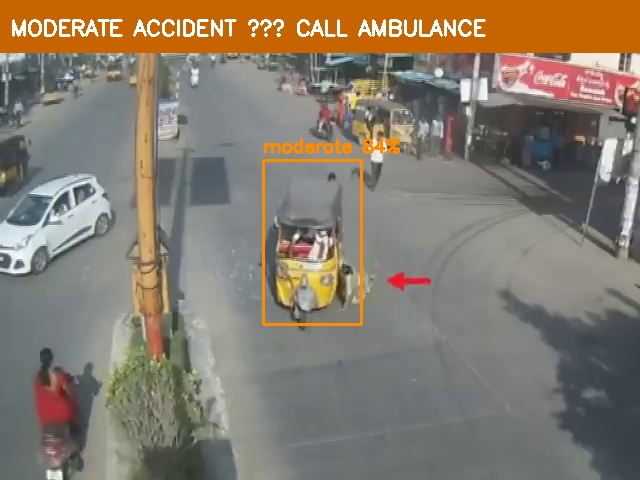

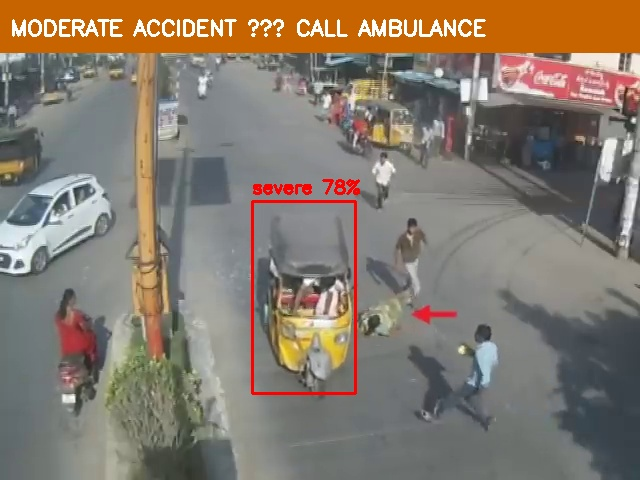

In [ ]:
from google.colab import files as colab_files

print("📁 Choose a video file to upload (mp4, avi, mov)...")
uploaded = colab_files.upload()

if uploaded:
    video_filename = list(uploaded.keys())[0]
    video_path = f"/content/{video_filename}"
    print(f"\n✅ Uploaded: {video_filename}")
    print("\nStarting accident detection...\n")
    output = detect_accidents_in_video(video_path)
else:
    print("No file uploaded.")

In [ ]:
from ultralytics import YOLO
from google.colab import drive
import cv2
import os

drive.mount('/content/drive')
model = YOLO("/content/drive/MyDrive/accident_detection_model/best.pt")

# Find the uploaded video automatically
video_path = None
for f in os.listdir("/content"):
    if f.endswith((".mp4", ".avi", ".mov")):
        video_path = f"/content/{f}"
        print(f"Found video: {f}")
        break

if not video_path:
    print("❌ No video found — run Cell 8 first to upload it")
else:
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    found_any = False

    print("Scanning all frames above 0.75 confidence...\n")

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1

        if frame_count % 5 != 0:
            continue

        results = model(frame, verbose=False)[0]
        for box in results.boxes:
            conf     = float(box.conf[0])
            cls_name = model.names[int(box.cls[0])]
            if conf >= 0.75:
                found_any = True
                print(f"Frame {frame_count}: {cls_name} — {conf:.0%}")

    cap.release()

    if not found_any:
        print("✅ No detections above 0.75 — model is clean on this video!")
        print("   The alert must be coming from a previous run's cooldown. Try restarting runtime.")
    else:
        print("\n⬆️ These frames are causing false alarms.")
        print("   Solution: raise CONFIDENCE_THRESHOLD to 0.85 or 0.90")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found video: When My City s Traffic Lights Turn Off __ ViralHog (5).mp4
Scanning all frames above 0.75 confidence...

Frame 115: moderate — 76%
Frame 220: moderate — 80%
Frame 245: moderate — 76%

⬆️ These frames are causing false alarms.
   Solution: raise CONFIDENCE_THRESHOLD to 0.85 or 0.90


## 💾 CELL 9 — Download the Output Video
Download the annotated video with detection boxes drawn on it.

In [ ]:
output_video = "/content/output_detected.mp4"

if os.path.exists(output_video):
    print("📥 Downloading annotated output video...")
    colab_files.download(output_video)
else:
    print("⚠️  No output video found. Run Cell 8 first.")

📥 Downloading annotated output video...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📋 CELL 10 — View Incident Log
See all accidents that were detected and logged.

In [ ]:
incidents = get_all_incidents()

if not incidents:
    print("No incidents logged yet. Run detection first.")
else:
    print(f"📋 Total incidents logged: {len(incidents)}")
    print("-" * 70)
    for inc in incidents:
        sms_status  = "✅ SMS sent" if inc["sms_sent"]  else "⚠️  SMS not sent"
        call_status = "✅ Call made" if inc["call_made"] else "⚠️  Call not made"
        print(f"Incident #{inc['id']}")
        print(f"  🕐 Time      : {inc['timestamp']}")
        print(f"  📍 Location  : {inc['location']}")
        print(f"  🎯 Confidence: {inc['confidence']:.0%}")
        print(f"  🏥 Hospital  : {inc['hospital']}")
        print(f"  📲 Alerts    : {sms_status} | {call_status}")
        print("-" * 70)

📋 Total incidents logged: 3
----------------------------------------------------------------------
Incident #3
  🕐 Time      : 2026-05-10T12:37:58.508629
  📍 Location  : NH-48, Delhi-Gurgaon Highway
  🎯 Confidence: 76%
  🏥 Hospital  : Emergency Services
  📲 Alerts    : ⚠️  SMS not sent | ⚠️  Call not made
----------------------------------------------------------------------
Incident #2
  🕐 Time      : 2026-05-10T12:37:10.588615
  📍 Location  : NH-48, Delhi-Gurgaon Highway
  🎯 Confidence: 91%
  🏥 Hospital  : Emergency Services
  📲 Alerts    : ⚠️  SMS not sent | ⚠️  Call not made
----------------------------------------------------------------------
Incident #1
  🕐 Time      : 2026-05-10T12:35:21.994115
  📍 Location  : NH-48, Delhi-Gurgaon Highway
  🎯 Confidence: 76%
  🏥 Hospital  : Emergency Services
  📲 Alerts    : ⚠️  SMS not sent | ⚠️  Call not made
----------------------------------------------------------------------


## 📊 CELL 11 — Quick Stats + Charts

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

incidents = get_all_incidents()

if not incidents:
    print("No data yet. Run detection first.")
else:
    total    = len(incidents)
    sms_sent  = sum(1 for i in incidents if i["sms_sent"])
    calls     = sum(1 for i in incidents if i["call_made"])
    avg_conf  = sum(i["confidence"] for i in incidents) / total

    print(f"📊 Summary")
    print(f"  Total incidents : {total}")
    print(f"  SMS alerts sent : {sms_sent}")
    print(f"  Calls made      : {calls}")
    print(f"  Avg confidence  : {avg_conf:.0%}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Accident Detection — Incident Summary", fontsize=14, fontweight="bold")

    # Bar chart — alert status
    axes[0].bar(["Total\nIncidents", "SMS\nSent", "Calls\nMade"],
                [total, sms_sent, calls],
                color=["#ef4444", "#f59e0b", "#22c55e"])
    axes[0].set_title("Alert Status")
    axes[0].set_ylabel("Count")

    # Confidence distribution
    confs = [i["confidence"] * 100 for i in incidents]
    axes[1].hist(confs, bins=10, color="#6366f1", edgecolor="white")
    axes[1].set_title("Confidence Score Distribution")
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_ylabel("Number of incidents")

    plt.tight_layout()
    plt.savefig("/content/incident_stats.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("\n📥 Chart saved. Download with:  files.download('/content/incident_stats.png')")

## 🧪 CELL 12 — Test Alert System (Without Real Twilio)
Test that everything works — simulates an accident without needing a real video.

In [ ]:
print("🧪 Running alert system test...")
print("   (If Twilio is not configured, SMS/call will be skipped — that's okay for testing)\n")

result = trigger_alert(
    confidence=0.87,
    location="Test Location — NH-48 Km 22",
    lat=CAMERA_LATITUDE,
    lon=CAMERA_LONGITUDE
)

if result:
    print(f"\n✅ Test complete!")
    print(f"   Incident ID : #{result['incident_id']}")
    print(f"   Hospital    : {result['hospital']}")
    print(f"   SMS sent    : {result['sms_sent']}")
    print(f"   Call made   : {result['call_made']}")
else:
    print("Alert was skipped (cooldown active or error).")

---
## ✅ You're all set!

| Cell | What it does |
|------|-------------|
| 1 | Install libraries |
| 2 | Set your config (Twilio keys, location) |
| 3 | Create database |
| 4 | Alert system (SMS + call) |
| 5 | Load YOLO model |
| 6 | Train custom model (optional) |
| 7 | Detection function |
| 8 | **Upload & analyze your video** |
| 9 | Download output video |
| 10 | View incident log |
| 11 | Charts & stats |
| 12 | Test the alert system |

### 🚀 Recommended order for first run:
**Cell 1 → 2 → 3 → 4 → 5 → 7 → 12 (test) → 8 (upload video)**

### 📌 Tips:
- Always select **T4 GPU** in Runtime settings for 10x faster detection
- Save this notebook to your **Google Drive** so you don't lose it
- For presentation, run Cell 11 to show the stats chart to your professor